In [11]:
import sqlite3
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

"""# Display options
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
plt.rcParams.update({
    "figure.figsize": (8, 5),
})"""

# Where to find the DB and where to save figures
DB_PATH = Path("results_combined.db")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

In [12]:
con = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("SELECT * FROM runs", con)
con.close()

In [13]:
def convert_string_to_int_or_float(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    if "." in s:
        try:
            f=float(s)
            if f.is_integer():
                return int(f)
            return f
        except:
            pass
    try:
        return int(s)
    except Exception:
        return None

In [14]:
numbers_as_strings = ["exact", "algo_res"]
for col in numbers_as_strings:
    df[col] = df[col].apply(convert_string_to_int_or_float)
df = df[df["exact"] > 0].copy()
df['signed_bias'] = df['ratio'] - 1.0
df.loc[~np.isfinite(df['signed_bias']), 'signed_bias'] = np.nan

df["time_sec_log2"] = df["time_sec"].apply(math.log2)

In [15]:
for col in df.columns:
    print(f"Column: {col}, Type: {df[col].dtype}")


Column: id, Type: int64
Column: M, Type: int64
Column: M2, Type: int64
Column: N, Type: int64
Column: exact, Type: object
Column: algo_res, Type: object
Column: ratio, Type: float64
Column: time_sec, Type: float64
Column: algo, Type: object
Column: max_size, Type: float64
Column: EPSILON, Type: float64
Column: DELTA, Type: float64
Column: log2_exact, Type: float64
Column: log2_algo_res, Type: float64
Column: system, Type: object
Column: minimize_version, Type: object
Column: Seed, Type: object
Column: created_at, Type: object
Column: signed_bias, Type: float64
Column: time_sec_log2, Type: float64


In [16]:
def success_rate_by(df, by: list[str], eps: float):
    ok = df.copy()
    ok['success'] = (ok['rel_err'] <= eps).astype(float)
    g = ok.groupby(by)['success']
    out = pd.DataFrame({
        'success_rate': g.mean(),
        'count': g.size()
    }).reset_index()
    return out

def ensure_sorted_by_numeric(df, col: str):
    try:
        return df.sort_values(col)
    except Exception:
        return df

def pivot_grid(df, x_col, y_col, value_col, agg='median'):
    # Aggregate value by (x,y), return pivoted grid
    agg_df = df.groupby([x_col, y_col])[value_col].agg(agg).reset_index()
    grid = agg_df.pivot(index=y_col, columns=x_col, values=value_col)
    return grid

def plot_heatmap(grid, title, xlabel, ylabel, zlabel, xlimits, ylimits,  log_z=False, log_base=None):
    # Basic imshow heatmap (single plot)

    plt.imshow(grid.values, aspect='auto', origin='lower', extent=(xlimits[0]-0.5, xlimits[1]+0.5, ylimits[0]-0.5, ylimits[1]+0.5))
    plt.title(title)
    """plt.xticks(ticks=xvals, labels=xvals)
    plt.yticks(ticks=yvals, labels=yvals)"""
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    cbar = plt.colorbar(label=zlabel)
    if log_z:

        zticks = cbar.get_ticks()
        zlabels = [rf"${log_base}^{{{int(v) if v.is_integer() else v}}}$" for v in zticks]
        cbar.set_ticklabels(zlabels)
    
    

def scaling_fit(df, x_col, y_col, group_col='algo'):
    # Fit log-log slope per group; returns DataFrame of slopes and intercepts
    rows = []
    for k, g in df.groupby(group_col):
        x = g[x_col].values
        y = g[y_col].values
        mask = np.isfinite(x) & np.isfinite(y) & (x>0) & (y>0)
        x = x[mask]
        y = y[mask]
        if len(x) >= 3:
            lx = np.log(x)
            ly = np.log(y)
            slope, intercept = np.polyfit(lx, ly, 1)
            rows.append((k, slope, intercept, len(x)))
    return pd.DataFrame(rows, columns=[group_col, 'slope', 'intercept', 'n_points'])

def median_by(df, keys: list[str], val: str):
    return df.groupby(keys)[val].median().reset_index()


C:\Users\lenna\AppData\Local\Temp\ipykernel_48364\3483640277.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.set_ticklabels(zlabels)


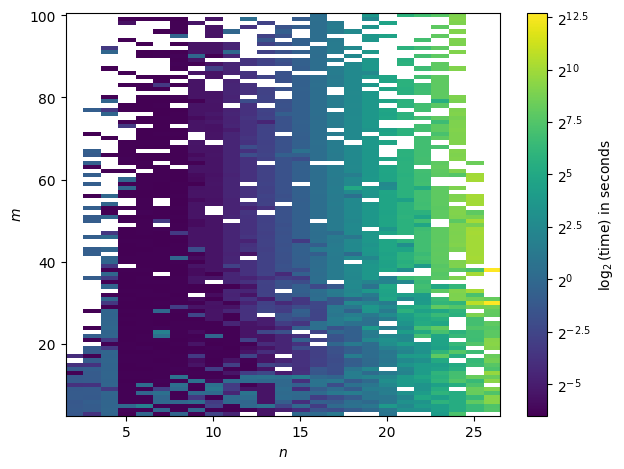

C:\Users\lenna\AppData\Local\Temp\ipykernel_48364\3483640277.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.set_ticklabels(zlabels)


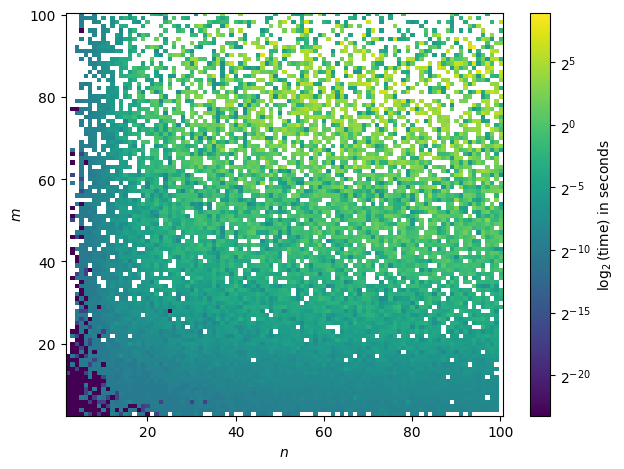

C:\Users\lenna\AppData\Local\Temp\ipykernel_48364\3483640277.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.set_ticklabels(zlabels)


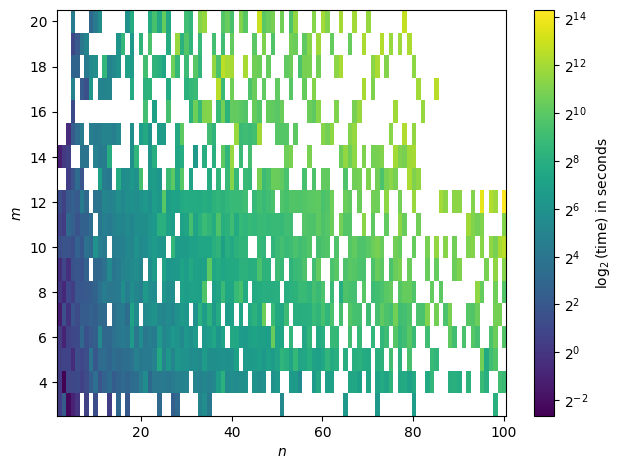

C:\Users\lenna\AppData\Local\Temp\ipykernel_48364\3483640277.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.set_ticklabels(zlabels)


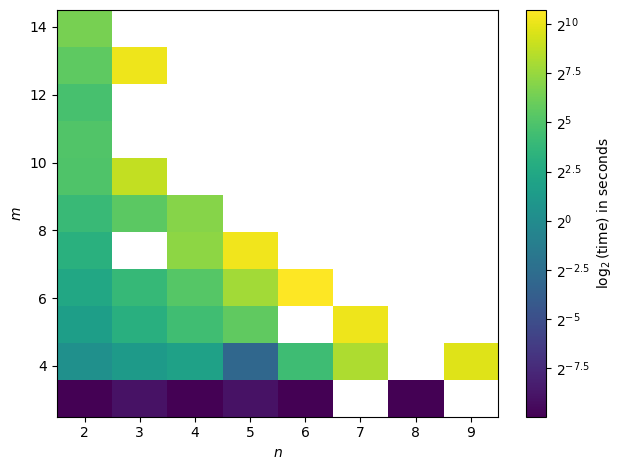

In [17]:
algos = sorted(df['algo'].dropna().unique())
xmax = {"BruteForce": 26, "BruteForcePowerset": 100, "DependentFPRAS":100, "MainFPRAS": 10}
ymax = {"BruteForce": 100, "BruteForcePowerset": 100, "DependentFPRAS":20, "MainFPRAS": 14}
for algo in algos:
    sub = df[df['algo']==algo].copy()
    if len(sub) < 5:
        continue
    try:
        sub = sub[sub['N']<=xmax[algo]].copy()
        sub = sub[sub['M2']<=ymax[algo]].copy()
        grid_t = pivot_grid(sub, x_col='N', y_col='M2', value_col='time_sec_log2', agg='median')
        xlimits = (int(grid_t.columns.min()), int(grid_t.columns.max()))
        ylimits = (int(grid_t.index.min()), int(grid_t.index.max()))
        plt.figure()
        plot_heatmap(grid_t, "", xlabel=r"$n$", ylabel=r"$m$", zlabel=r"$\log_2(\mathsf{time})\text{ in seconds}$", xlimits=xlimits, ylimits=ylimits, log_z=True, log_base=2)
        plt.tight_layout()
        plt.savefig(FIG_DIR / f"heatmap_time_{algo}.png", dpi=160)
        plt.show()
    except Exception as e:
        print(f"Skipping time heatmap for {algo}: {e}")

,algo,slope,intercept,n_points
0,BruteForce,4.281575,-9.919744,29
1,BruteForcePowerset,1.740002,-10.786349,109
2,DependentFPRAS,2.091892,-1.895434,120
3,MainFPRAS,0.658550,1.209000,8


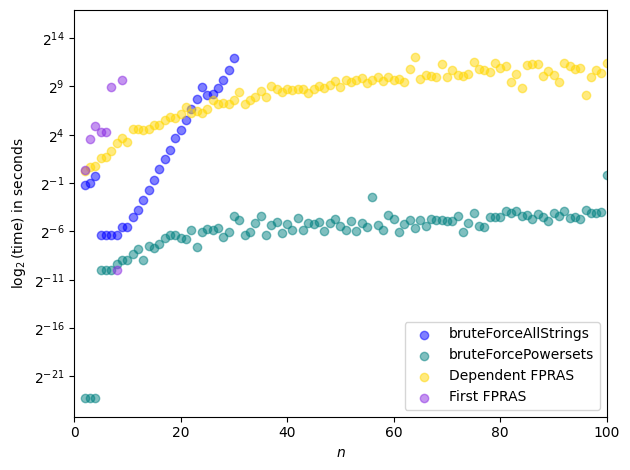

,algo,slope,intercept,n_points
0,BruteForce,0.845503,-3.757171,141
1,BruteForcePowerset,1.423470,-7.610654,284
2,DependentFPRAS,0.830950,3.722957,102
3,MainFPRAS,5.790669,-8.861898,11


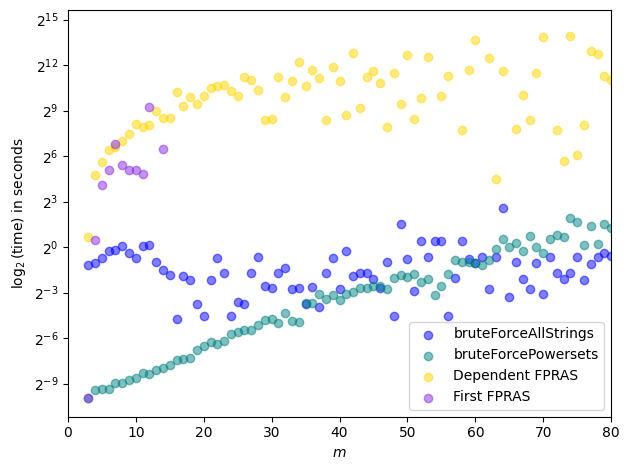

In [18]:
colors_algo = {
    "BruteForce": "blue",
    "BruteForcePowerset": "teal",
    "DependentFPRAS": "gold",
    "MainFPRAS": "blueviolet",
}
labels_algo = {
    "BruteForce": "bruteForceAllStrings",
    "BruteForcePowerset": "bruteForcePowersets",
    "DependentFPRAS": "Dependent FPRAS",
    "MainFPRAS": "First FPRAS",
}

med_N = median_by(df, keys=['algo','N'], val='time_sec')
fit_N = scaling_fit(med_N.rename(columns={'N':'x','time_sec':'y'}), x_col='x', y_col='y', group_col='algo')
display(fit_N)

plt.figure()
for algo, g in med_N.groupby('algo'):
    g = g[g['N']>0]
    plt.scatter(g['N'], g['time_sec'], color=colors_algo[algo], label=labels_algo[algo], alpha=0.5)

plt.yscale('log', base=2)
plt.xlabel(r"$n$")
plt.ylabel(r"$\log_2(\mathsf{time})\text{ in seconds}$")
plt.gca().set_xlim([0, 100])
plt.legend(labels=["bruteForceAllStrings", "bruteForcePowersets", "Dependent FPRAS", "First FPRAS"])
plt.tight_layout()
plt.savefig(FIG_DIR / "scaling_time_vs_N.png", dpi=160)
plt.show()

med_M2 = median_by(df, keys=['algo','M2'], val='time_sec')
fit_M2 = scaling_fit(med_M2.rename(columns={'M2':'x','time_sec':'y'}), x_col='x', y_col='y', group_col='algo')
display(fit_M2)

plt.figure()
for algo, g in med_M2.groupby('algo'):
    g = g[g['M2']>0]
    plt.scatter(g['M2'], g['time_sec'], color=colors_algo[algo], label=labels_algo[algo], alpha=0.5)

plt.yscale('log', base=2)
plt.xlabel(r"$m$")
plt.ylabel(r"$\log_2(\mathsf{time})\text{ in seconds}$")
plt.gca().set_xlim([0, 80])
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "scaling_time_vs_M2.png", dpi=160)
plt.show()

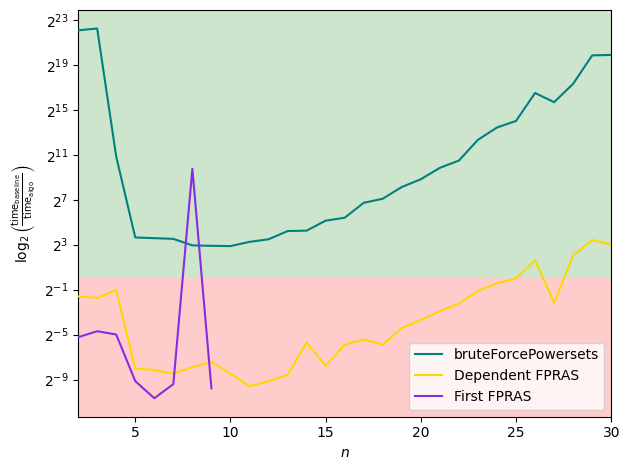

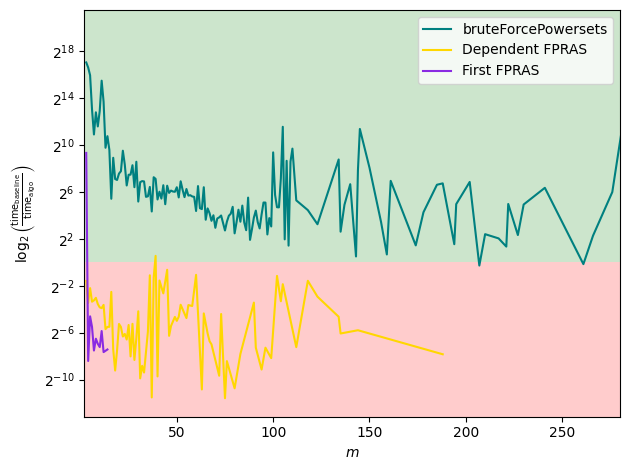

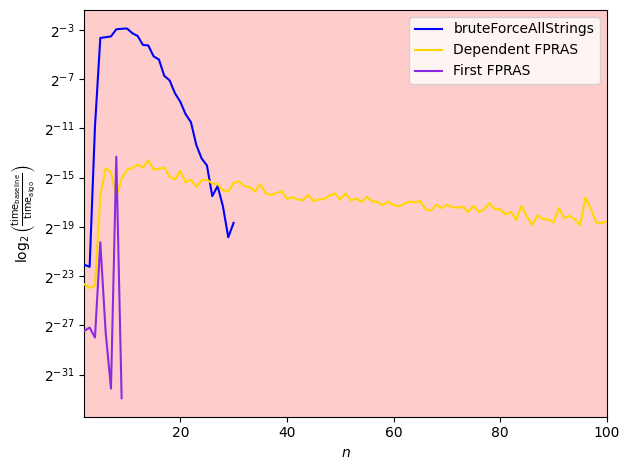

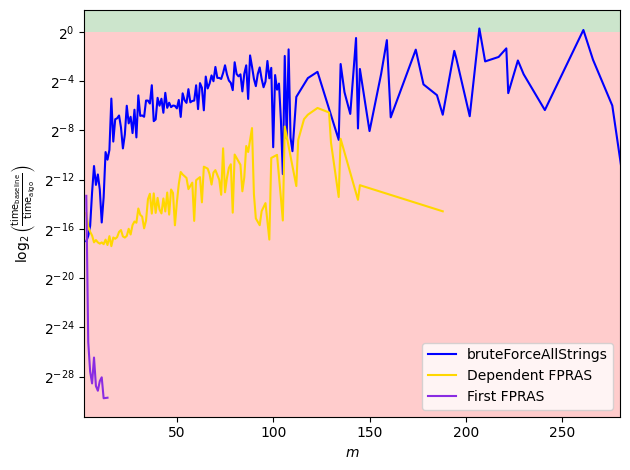

In [19]:
# Speedup vs baselines (BruteForce and BruteForcePowerset)
def median_time_table(df):
    return df.groupby(['algo','N','M2'])['time_sec'].median().reset_index()

med = median_time_table(df)

def compute_speedup(med_df, baseline_algo: str):
    base = med_df[med_df['algo']==baseline_algo][['N','M2','time_sec']].rename(columns={'time_sec':'base_time'})
    rows = []
    for algo in sorted(med_df['algo'].unique()):
        if algo == baseline_algo:
            continue
        cur = med_df[med_df['algo']==algo][['N','M2','time_sec']]
        merged = pd.merge(cur, base, on=['N','M2'], how='inner')
        if merged.empty:
            continue
        merged['speedup'] = merged['base_time'] / merged['time_sec']
        merged['algo'] = algo
        rows.append(merged[['algo','N','M2','speedup']])
    if rows:
        return pd.concat(rows, ignore_index=True)
    return pd.DataFrame(columns=['algo','N','M2','speedup'])

for baseline in ['BruteForce','BruteForcePowerset']:
    sp = compute_speedup(med, baseline_algo=baseline)
    if sp.empty:
        print(f"No overlapping data to compute speedups vs {baseline}.")
        continue

    # Speedup vs N
    aggN = sp.groupby(['algo','N'])['speedup'].median().reset_index()
    plt.figure()
    for algo, g in aggN.groupby('algo'):
        g = ensure_sorted_by_numeric(g, 'N')
        plt.plot(g['N'], g['speedup'], color=colors_algo[algo], label=labels_algo[algo])
    plt.yscale('log', base=2)
    plt.xlabel(r"$n$")
    plt.ylabel(r"$\log_2\left( \frac{\mathsf{time}_{\mathrm{baseline}}}{\mathsf{time}_{\mathrm{algo}}} \right)$")
    ax = plt.gca()
    if baseline == "BruteForce":
        ax.set_xlim([2, 30])
    else:
        ax.set_xlim([2, 100])
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax)
    ax.axhspan(ymin, 1, facecolor='red', alpha=0.2, zorder=0)
    ax.axhspan(1,  ymax, facecolor='green', alpha=0.2, zorder=0)
    
    for line in ax.lines:
        line.set_zorder(3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"speedup_vs_N_vs_{baseline}.png", dpi=160)
    plt.show()

    # Speedup vs M2
    aggM = sp.groupby(['algo','M2'])['speedup'].median().reset_index()
    plt.figure()
    for algo, g in aggM.groupby('algo'):
        g = ensure_sorted_by_numeric(g, 'M2')
        plt.plot(g['M2'], g['speedup'], color=colors_algo[algo], label=labels_algo[algo])
    plt.yscale('log', base=2)
    ax = plt.gca()
    ax.set_xlim([2, 280])
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax)
    ax.axhspan(ymin, 1, facecolor='red', alpha=0.2, zorder=0)
    ax.axhspan(1,  ymax, facecolor='green', alpha=0.2, zorder=0)

    
    for line in ax.lines:
        line.set_zorder(3)
    plt.xlabel(r"$m$")
    plt.ylabel(r"$\log_2\left( \frac{\mathsf{time}_{\mathrm{baseline}}}{\mathsf{time}_{\mathrm{algo}}} \right)$")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"speedup_vs_M2_vs_{baseline}.png", dpi=160)
    plt.show()

In [20]:
# Outlier diagnostics: top 1% largest |1 - ratio| per algorithm
outlier_frames = []
for algo, g in df.groupby('algo'):
    if "BruteForce" not in algo:
        if g.empty:
            continue
        thr = g['signed_bias'].quantile(0.99)
        out = g[g['signed_bias'] >= thr].copy()
        out['algo'] = algo
        outlier_frames.append(out[['algo','N','M2','time_sec','signed_bias','exact','algo_res']].sort_values('signed_bias', ascending=False).head(20))

if outlier_frames:
    outliers = pd.concat(outlier_frames, ignore_index=True)
    display(outliers.head(100))
else:
    print("No outliers found or insufficient data.")

,algo,N,M2,time_sec,signed_bias,exact,algo_res
0,DependentFPRAS,77,4,167.788389,0.028554,75557863725914323419136,77715322473387186884144
1,DependentFPRAS,51,5,346.611853,0.023038,2251799813685248,2303676049096139
2,DependentFPRAS,7,4,1.581674,0.022200,127,129.819463
3,DependentFPRAS,74,4,149.345750,0.022184,9444732965739290427392,9654258807448510563177
4,DependentFPRAS,36,4,37.388341,0.020494,45812984491,46751892187
5,DependentFPRAS,68,4,112.806527,0.020054,72723460248141,74181851900866
6,DependentFPRAS,66,4,168.740187,0.019259,36893488147419103232,37604035862125969096
7,DependentFPRAS,64,8,234.911230,0.018861,13835058055282163712,14096006353027050850
8,DependentFPRAS,54,4,101.330378,0.018800,139583862445,142208049760
9,DependentFPRAS,50,5,129.991383,0.018628,965057063007964,983033883100151
